# TS-DAR Tutorial for Hydrogen Catalysis Dataset

Data analyzed is from: 
Caitlin A. McCandler, Chatipat Lorpaiboon, Timothy C. Berkelbach, Jutta Rogal; Markov State Models for Tracking Reaction Dynamics on Catalytic Nanoparticles. J. Chem. Theory Comput. 28 April 2026; 22 (8): 3851–3859. https://doi-org.ezproxy.library.wisc.edu/10.1021/acs.jctc.6c00277

Data files can be found at: https://zenodo.org/records/22133333


In [ ]:
from datetime import datetime

start = datetime.now()

import os
import numpy as np
import torch
import torch.nn as nn
import glob
from pathlib import Path
import sys
import yaml
import csv
import argparse
import matplotlib.pyplot as plt

from torch.utils.data.dataloader import DataLoader
from torch.utils.data import random_split

from tsdar.utils import set_random_seed
from tsdar.loss import Prototypes
from tsdar.model import TSDAR, TSDARLayer, TSDAREstimator
from tsdar.dataprocessing import Preprocessing

if torch.cuda.is_available():
    device = torch.device('cuda')
    print('cuda is available')
else:
    device = torch.device('cpu')
    print('cpu')

## Example Training Script

Example script to run TS-DAR training that allows for customizable input of TS-DAR hyperparameters.

**Note: input training data not provided only example script for training**

Results of TS-DAR training provided



In [ ]:



# Information about the Arguments for input 
parser = argparse.ArgumentParser(description='Single Trial TS-DAR')
parser.add_argument('--attempt',        type=str,   required=True,  help='Attempt number')
parser.add_argument('--trial',          type=int,   required=True,  help='Trial number')
parser.add_argument('--pretrain',       type=int,   required=True,  help='Number of pretrain epochs (no dispersion loss)')
parser.add_argument('--tot_epoch',      type=int,   required=True,  help='Total number of epochs (including pretraining)')
parser.add_argument('--lagtime',        type=int,   required=True,  help='Lagtime for loading in time-lagged data')
parser.add_argument('--num_states',     type=int,   required=True,      help='Number of macrostates (default: 4)')

# Optional args with defaults
parser.add_argument('--num_trials',     type=int,   default=5,      help='Number of total trials (default: 5)')
parser.add_argument('--lr',             type=float, default=1e-3,   help='Learning rate (default: 1e-3)')
parser.add_argument('--mode',           type=str,   default='regularize', help='Mode for learning (default: regularize)')
parser.add_argument('--beta',           type=float, default=0.01,   help='Beta value for dispersion loss (default: 0.01)')
parser.add_argument('--batch_size',     type=int,   default=1000,   help='Batch size (default: 1000)')
parser.add_argument('--input_dim',      type=int,   default=131,    help='Feature input dimension (default: 131)')
parser.add_argument('--output_dim',     type=int,   default=3,      help='Hypersphere dimension (default: 3)')
parser.add_argument('--nn_structure',   type=str,   default='90,62,43,16', help='Comma-separated hidden layer sizes (default: 90,62,43,16)')
parser.add_argument('--dataset',        type=str,   default='DATA SET NAME', help='Dataset name for labeling purposes (default: "DATA SET NAME")')
parser.add_argument('--feature_str',    type=str,   default='FEATURE STRING', help='Feature input string (default: "FEATURE STRING")')
parser.add_argument('--seed',        type=int,   default=None,  help='Random seed to initiate NN, default is to use trial number')

args = parser.parse_args()

## Attempt / Trial ##
attempt = args.attempt
trial   = args.trial

print(f"Attempt {attempt} - Trial {trial}") 

## Parameter List ##
num_states      = args.num_states
num_trials      = args.num_trials
learning_rate   = args.lr
mode            = args.mode
beta            = args.beta
batch_size      = args.batch_size
input_feat_dim  = args.input_dim
output_feat_dim = args.output_dim
pretrain        = args.pretrain
n_epochs        = args.tot_epoch
lagtime         = args.lagtime
seed            = args.seed

# Set random seed (use trial number to ensure each is different)
if seed == None: 
    seed = trial
    seed_string = "Trial Number"
else:
    pass
    seed_string = "See YAML Files"

set_random_seed(seed)

# Dataset information
data_set_name        = args.dataset
feature_input_string = args.feature_str

# Parse hidden layer configuration from comma-separated string
hidden_layers = [int(x) for x in args.nn_structure.split(',') if x.strip()]
nn_structure = [input_feat_dim] + hidden_layers + [output_feat_dim]

## Print parameters ##
output_csv_txt_filename = f"attempt_{attempt}_hyperparams"
# Save CSV for Google Sheet
with open(f"{output_csv_txt_filename}.csv", "w", newline="") as f:
    writer = csv.writer(f)

    writer.writerow([
        f"Attempt {attempt}",
        data_set_name,
        feature_input_string,
        num_states,
        num_trials,
        input_feat_dim,
        learning_rate,
        mode,
        batch_size,
        beta,
        output_feat_dim,
        pretrain,
        n_epochs,
        lagtime,
        nn_structure,
        seed_string
    ])

# Make YAML for future pipelines
hyperparameters = {
    "attempt": attempt,
    "trial": trial,
    "num_trials": num_trials,
    "num_states": num_states,
    "data_set_name": data_set_name,
    "input_features": input_feat_dim,
    "feature_input_string": feature_input_string,
    "learning_rate": learning_rate,
    "mode": mode,
    "batch_size": batch_size,
    "beta": beta,
    "feat_dim": output_feat_dim,
    "pretrain": pretrain,
    "n_epochs": n_epochs,
    "lagtime": lagtime,
    "nn_structure": nn_structure,
    "random_seed": seed
}

yaml_file = f"attempt_{attempt}_trial_{trial}_hyperparams.yaml"

with open(yaml_file, "w") as f:
    yaml.dump(hyperparameters, f, sort_keys=False)

# Print for Presentation
with open(f"{output_csv_txt_filename}.txt","w") as f:
    print(f"Attempt {attempt}", file=f)
    print(f"Data Set: {data_set_name}", file=f)
    print(f"N_states: {num_states}", file=f)
    print(f"Number of Trials: {num_trials}", file=f)
    print(f"Number of Input Features: {input_feat_dim}", file=f)
    print(f"Feature Input: {feature_input_string}", file=f)
    print(f"Learning Rate {learning_rate}", file=f)
    print(f"Mode: {mode}", file=f)
    print(f"Batch Size: {batch_size}", file=f)
    print(f"Beta: {beta}", file=f)
    print(f"Feat_dim: {output_feat_dim}", file=f)
    print(f"Pretrain: {pretrain}", file=f)
    print(f"N_epochs: {n_epochs}", file=f)
    print(f"Lagtime: {lagtime}", file=f)
    print(f"NN Structure: {nn_structure}", file=f)
    print(f"Random Seed: {seed_string}",file=f)

# Load in data
file = # INSERT PATH TO DATA FILE HERE

data = np.load(file, allow_pickle=True).astype(np.float32)
data = [traj[~np.isnan(traj).any(axis=1)] for traj in data]

# Preprocessing data
pre = Preprocessing(dtype=np.float32)
dataset = pre.create_dataset(lag_time=lagtime,data=data)

# Make directory for Attempt
directory_name = f"./Attempt_{attempt}_TSDAR_Output"
os.makedirs(directory_name,exist_ok=True)

base_dir = os.path.abspath(directory_name)

val = int(len(dataset)*0.10) # 90:10 split
train_data, val_data = torch.utils.data.random_split(dataset, [len(dataset)-val, val]) 
# way the dataset is split depends on the underlying pseudo-random number generator

loader_train = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=True,
)

loader_val = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True,
)
print("Done loading in data")

trial_dir = os.path.join(base_dir, f"trial_{trial}")
os.makedirs(trial_dir, exist_ok=True)
os.chdir(trial_dir)

lobe = TSDARLayer(nn_structure, n_states=num_states)
lobe = lobe.to(device=device)
print(f"Starting to train trial {trial} now")
tsdar = TSDAR(lobe=lobe, learning_rate=learning_rate, device=device, mode=mode, beta=beta, feat_dim=output_feat_dim, n_states=num_states, pretrain=pretrain)
tsdar_model = tsdar.fit(loader_train, n_epochs=n_epochs, validation_loader=loader_val).fetch_model()

print(f"Done training trial {trial}")
validation_vamp = tsdar.validation_vamp
validation_dis = tsdar.validation_dis
validation_prototypes = tsdar.validation_prototypes

training_vamp = tsdar.training_vamp
training_dis = tsdar.training_dis

np.save(('validation_vamp.npy'),validation_vamp)
np.save(('validation_dis.npy'),validation_dis)
np.save(('validation_prototypes.npy'),validation_prototypes)

np.save(('training_vamp.npy'),training_vamp)
np.save(('training_dis.npy'),training_dis)

hypersphere_embs = tsdar_model.transform(data=data,return_type='hypersphere_embs')
metastable_states = tsdar_model.transform(data=data,return_type='states')

tsdar_estimator = TSDAREstimator(tsdar_model)
ood_scores = tsdar_estimator.fit(data).ood_scores
state_centers = tsdar_estimator.fit(data).state_centers

hypersphere_embs = np.array(hypersphere_embs,dtype=object)
metastable_states = np.array(metastable_states,dtype=object)
ood_scores = np.array(ood_scores,dtype=object)

np.save(('hypersphere_embs.npy'), hypersphere_embs, allow_pickle=True)
np.save(('metastable_states.npy'), metastable_states, allow_pickle=True)
np.save(('ood_scores.npy'), ood_scores, allow_pickle=True)
np.save(('state_centers.npy'), state_centers)

torch.save(tsdar_model.lobe.state_dict(), 'model.pt')

elapsed = datetime.now() - start
hours, remainder = divmod(elapsed.total_seconds(), 3600)
minutes, seconds = divmod(remainder, 60)
print(f"Elapsed: {int(hours)}:{int(minutes)}:{seconds:.2f}")


## Plotting TS-DAR Output

Example TS-DAR output is from "Attempt 1 Trial 1" 
Hyperparameters used for training are reported in 

### Define Functions and Load in Data

In [ ]:
# Config loader
def load_config(path: str | Path) -> dict:
    cfg_path = Path(path)
    if not cfg_path.is_file():
        raise FileNotFoundError(f"Config YAML not found: {cfg_path}")
    print(f"[INFO] Loading config from: {cfg_path.resolve()}")
    with cfg_path.open("r") as fh:
        return yaml.safe_load(fh)

# Function to plot ITS
def plot_its(lagtime_list, timescales, n_timescales=10, title="Implied Timescale Plot", title_fontsize=20):
    # Plot an Implied timescale test
    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(n_timescales):
        ax.plot(lagtime_list, np.log10(timescales[:, i]), linewidth=3)
    y_min = int(np.floor(np.log10(timescales).min()))
    y_max = int(np.ceil(np.log10(timescales).max()))
    ytick_vals = list(range(y_min, y_max + 1))
    ytick_labels = [f'$10^{{{v}}}$' for v in ytick_vals]
    plt.yticks(ytick_vals, labels=ytick_labels, fontsize=20)
    plt.xticks(fontsize=15)
    plt.xlabel('lagtime (steps)', fontsize=20)
    plt.ylabel('ITS (steps)', fontsize=20)
    plt.title(title, fontsize=title_fontsize)
    ax.tick_params(axis='both', direction='in', width=3, length=8)
    for spine in ax.spines.values():
        spine.set_linewidth(3)
    return fig, ax

## Sample code for running the pipeline with a config file (uncomment to use argparse):

# parser = argparse.ArgumentParser(description="Pipeline to test TS-DAR models on TRP-Cage data. Outputs FES and ITS plots.")
# parser.add_argument(
#     "--config",
#     "-c",
#     required=True,
#     help="Path to the YAML configuration file.",
# )
# args = parser.parse_args()

# Load configuration
#cfg = load_config(args.config)
cfg = load_config("attempt_1_trial_1_hyperparams.yaml")  # Example usage, replace with your config file path or argument parsing

attempt = cfg.get("attempt", "unknown_attempt")
trial = cfg.get("trial", "unknown_trial")
print(f"[INFO] Attempt: {attempt}, Trial: {trial}")
num_states = int(cfg.get("num_states"))
data_set_name = cfg.get("data_set_name", "unknown_data_set")
pretrain = cfg.get("pretrain")
n_epochs = cfg.get("n_epochs")
nn_structure = cfg.get("nn_structure")
training_lagtime = cfg.get("lagtime")
num_trials = cfg.get("num_trials", 5)
feat_dim = cfg.get("feat_dim", 3)


# Load TS-DAR state assignments and OOD Scores
interval = 10 # interval for plotting to make plotting quicker
attempt_file_path = f'trial_{trial}/'
model_states = np.load(f'{attempt_file_path}/metastable_states.npy',allow_pickle=True)
all_model_states = np.concatenate(model_states)[::interval]

ood_scores = np.load(f'{attempt_file_path}/ood_scores.npy', allow_pickle=True)
ood_scores = np.concatenate(ood_scores)[::interval]

# Load in tICA trajectory 
tica_trajs = np.load('tica_projection_clean.npy')
tica_trajs = [traj[~np.isnan(traj).any(axis=1)] for traj in tica_trajs]
all_tica_trajs = np.concatenate(tica_trajs)[::interval]

# Load in Geometric Labels
geometric_labels = np.load('geometric_classifications_clean.npy', allow_pickle=True)
geometric_labels = [traj[~np.isnan(traj)] for traj in geometric_labels]
all_geometric_labels = np.concatenate(geometric_labels)[::interval].astype(int)


### Plot VAMP-2 and DISP Loss

Text(0.5, 1.0, 'Attempt 1')

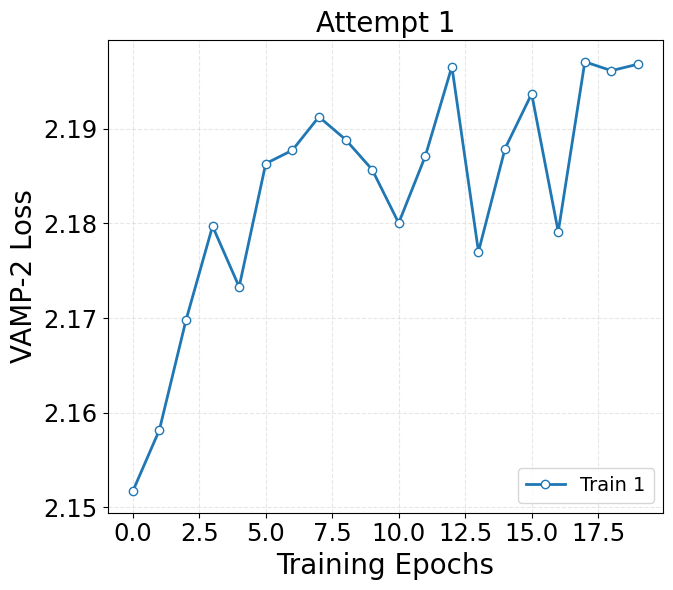

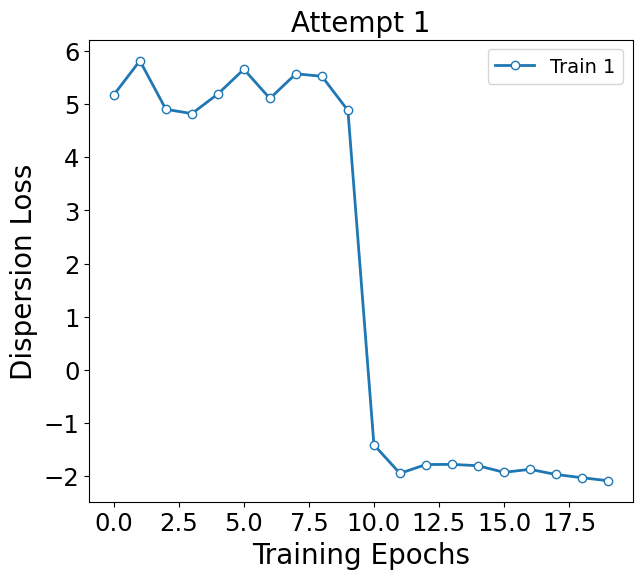

In [4]:
import matplotlib.pyplot as plt
import numpy as np

num_trials = 1
attempt = 1

val_vamp = []
for i in range(1,num_trials+1):
    file_path=f'./trial_{i}/validation_vamp.npy'
    dip = np.load(file_path)
    val_vamp.append(dip)

# Define custom colors for the line and markers
marker_face = 'white'

# Plot with custom colors, line width, and markers
fig = plt.figure(figsize=(8, 6))
for idx, dip in enumerate(val_vamp):
    plt.plot(dip, linewidth=2, marker='o', markersize=6, markerfacecolor=marker_face, linestyle='-', label=f'Train {idx + 1}')

# Set the axis labels 
plt.xlabel('Training Epochs', fontsize=20)
plt.ylabel('VAMP-2 Loss', fontsize=20)

# Customize tick parameters for readability
plt.xticks(fontsize=17.5)
plt.yticks(fontsize=17.5)
plt.gca().set_box_aspect(0.85)

# Add a dashed grid to improve the readability of the plot
plt.grid(alpha=0.3, linestyle='--')
plt.legend(loc='lower right', fontsize=14, markerscale=1, ncol=1)
plt.title(f"Attempt {attempt}",fontsize=20)
# Adjust the layout to ensure everything fits well
plt.tight_layout()
plt.savefig(f'TS_DAR_attempt_{attempt}_VAMP.png', dpi=900, bbox_inches='tight')

val_dip = []
for i in range(1,num_trials+1):
    file_path=f'./trial_{i}/validation_dis.npy'
    dip = np.load(file_path)
    n_epochs = len(dip)
    val_dip.append(dip)

plt.figure(figsize=(8, 6))
for idx, dip in enumerate(val_dip):
    plt.plot(dip, linewidth=2, marker='o', markersize=6, markerfacecolor=marker_face, linestyle='-', label=f'Train {idx + 1}')

# Set the axis labels
plt.xlabel('Training Epochs', fontsize=20)
plt.ylabel('Dispersion Loss', fontsize=20)

# Customize tick parameters for readability
plt.xticks(fontsize=17.5)
plt.yticks(fontsize=17.5)
plt.gca().set_box_aspect(0.85)
plt.legend(loc='upper right', fontsize=14, markerscale=1, ncol=1)
plt.title(f"Attempt {attempt}",fontsize=20)
#plt.savefig(f'TS_DAR_attempt_{attempt}_DISP.png', dpi=900, bbox_inches='tight')

### Plotting Hypersphere Embeddings 

In [ ]:
r = 1
pi = np.pi
cos = np.cos
sin = np.sin
phi, theta = np.mgrid[0.0:pi:100j, 0.0:2.0*pi:100j]
x = r*sin(phi)*cos(theta)
y = r*sin(phi)*sin(theta)
z = r*cos(phi)

features = np.load(f'{attempt_file_path}/hypersphere_embs.npy', allow_pickle=True)
features = np.concatenate(features)[::interval]
state_centers = np.load(f'{attempt_file_path}/state_centers.npy')

# Compute pairwise angular distances between metastable state centers
sim_mat = np.arccos(state_centers.dot(state_centers.T))
np.fill_diagonal(sim_mat, val=np.pi)
# Theoretical threshold (based on minimum angle between state centers)
thres = -np.cos(sim_mat.min()/2) + 1
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(
    x, y, z, rstride=2, cstride=2, color='pink', alpha=0.1,
    linewidth=100, antialiased=False
)

for i in range(num_states):
    ax.plot([0, state_centers[i,0]],
            [0, state_centers[i,1]],
            [0, state_centers[i,2]],
            linewidth=2, color='black', linestyle='--')

cb = ax.scatter(features[:,0],
                features[:,1],
                features[:,2],
                c=ood_scores[:],
                s=1, alpha=1, cmap='winter')
cb.set_clim(0.0, thres)

ccc = fig.colorbar(cb)
ccc.ax.tick_params(labelsize=10, length=3, width=1.5)
ccc.set_label('OOD score', fontsize=18)

ax.set_xlim([-1,1])
ax.set_ylim([-1,1])
ax.set_zlim([-1,1])
ax.set_xticks([-1,-0.5,0,0.5,1])
ax.set_yticks([-1,-0.5,0,0.5,1])
ax.set_zticks([-1,-0.5,0,0.5,1], [-1,-0.5,0,0.5,1])
ax.set_aspect("equal")
ax.tick_params(axis="both", labelsize=10, direction='out', length=7.5, width=2.5)

# ax.set_xlabel('z1', fontsize=15)
# ax.set_ylabel('z2', fontsize=15)
# ax.set_zlabel('z3', fontsize=15)
ax.set_title(f'Attempt {attempt} Trial {trial}', fontsize=15)

ax.view_init(elev=20, azim=50)

#plt.savefig(f'TS_DAR_attempt_{attempt}_trial_{trial}_hypersphere_plot.png',dpi=900, bbox_inches='tight')

### Plotting tICA projections colored by OOD scores and state assignments

In [ ]:
# State colors for plotting (up to 9 states, can be extended if needed)
colors = np.array(['#ef8a62', '#67a9cf', '#2166ac', '#b2182b', 'g', 'purple', 'grey', 'yellow', 'white'])
global_color_list = np.array(["#A56532","#C7925E","#C6361E", "#DD6929", "#F3B13F", "#F0D146",
                            "#65B442", "#B2DF46", "#EDFB96", "#A76290", "#E9C8E6",
                            "#4397CF", "#6FBACD", "#B9DEEE"])    
# TICS to plot (corrects for 0-indexing in Python)
for pair in [(1,2) , (1,3) , (2,3)]: # can modify to plot different pairs of tICs if desired
    x_axis = pair[0]
    y_axis = pair[1]

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))
    # --- Subplot 1: Geometric Labels ---
    ax1.scatter(all_tica_trajs[:, x_axis-1], all_tica_trajs[:, y_axis-1],
                s=5, c=global_color_list[all_geometric_labels], alpha=0.8, linewidth=0)
    ax1.set_xlabel(f"tIC {x_axis}", fontsize=20)
    ax1.set_ylabel(f"tIC {y_axis}", fontsize=20)
    ax1.tick_params(labelsize=15)
    ax1.set_title('Geometric Labels', fontsize=25)

    # --- Subplot 2: Metastable States ---
    ax2.scatter(all_tica_trajs[:, x_axis-1], all_tica_trajs[:, y_axis-1],
                s=5, color=colors[all_model_states], alpha=0.8, linewidth=0)
    ax2.set_xlabel(f"tIC {x_axis}", fontsize=20)
    ax2.set_ylabel(f"tIC {y_axis}", fontsize=20)
    ax2.tick_params(labelsize=15)
    ax2.set_title(f'Attempt {attempt} Trial {trial} - State Color', fontsize=25)

    # --- Subplot 3: OOD Scores ---
    sorted_indices = np.argsort(ood_scores)
    ood_scores_sorted = ood_scores[sorted_indices]
    tica_trajs_sorted = all_tica_trajs[sorted_indices]

    sc = ax3.scatter(tica_trajs_sorted[:, x_axis-1], tica_trajs_sorted[:, y_axis-1],
                    s=5, c=ood_scores_sorted, cmap='winter', alpha=0.8, linewidth=0)
    ax3.set_xlabel(f"tIC {x_axis}", fontsize=20)
    ax3.set_ylabel(f"tIC {y_axis}", fontsize=20)
    ax3.tick_params(labelsize=15)
    ax3.set_title(f'Attempt {attempt} Trial {trial} - OOD Scores', fontsize=25)
    cbar = fig.colorbar(sc, ax=ax3)
    cbar.ax.tick_params(labelsize=13)
    cbar.set_label('OOD Score', fontsize=20)

    plt.tight_layout()
    #plt.savefig(f'TS_DAR_attempt_{attempt}_trial_{trial}_tica_{x_axis}_{y_axis}_plots.png', dpi=900, bbox_inches='tight')



### Plotting ITS

In [ ]:

lagtime_array = np.arange(1, 1001)
num_timescales = num_states - 1

ITS = np.zeros((len(lagtime_array), num_timescales))

for i in range(len(lagtime_array)):
    counts = TransitionCountEstimator(
        lagtime=lagtime_array[i],
        count_mode="sliding"
    ).fit(model_states).fetch_model()

    msm = MaximumLikelihoodMSM(
        reversible=True,          # reversible_type='transpose' → reversible fit
        stationary_distribution_constraint=None
    ).fit(counts).fetch_model()

    # timescales_ in MSMBuilder = implied timescales (first num_timescales values)
    ITS[i] = msm.timescales(k=num_timescales)

title_string = f"Att{attempt}T{trial} - States: {num_states} (pre: {pretrain} tot: {n_epochs} lt: {training_lagtime})"
fig, ax = plot_its(lagtime_array, ITS, n_timescales=num_timescales, title=title_string, title_fontsize=15)
#plt.savefig(f'TS_DAR_attempt_{attempt}_trial_{trial}_ITS_plot.png', dpi=900, bbox_inches='tight')